In [1]:
from lightcurveanalysis import band_sep_FG,band_sep_med,band_sep_FG_and_med,band_sep_med_bach
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# FUNCTIONS

In [2]:
def get_source_data(data, source):
    source_data = data[data['Source'] == source]
    return source_data

# DATA

In [3]:
data = pd.read_csv('Unicum_last_flagged.csv',skiprows=[0,1,2],sep='\s+',on_bad_lines='skip')

aliases = {
        '0219+428': '3C66A',
        '0316+41': '3C84',
        '0355+508': 'NRAO150',
        '0851+202': 'OJ287',
        '1226+023': '3C273',
        '1253-055': '3C279',
        '1641+399': '3C345',
        '2200+420': 'BLLAC',
        '2251+158': '3C454.3',
        'Mrk501': 'Mrk501',
        '3c207': '3c207',
        'PKS1222+216': '1221+21',
        'BS0846+513': '0846+513',
        'CTA102': '2230+114'
    }

def replace_aliases(data, aliases):
    data_copy = data.copy()
    for original, alias in aliases.items():
        data_copy['Name'] = data_copy['Name'].replace(original, alias)
    return data_copy

data_with_aliases_replaced = replace_aliases(data, aliases)


#print(data['Name'].unique())
#len(data_with_aliases_replaced['Name'].unique())
#data

## FG

In [4]:

table7_path = r'C:/Users/Rupal Giri/Downloads/table7.dat'


fg_data = pd.read_csv(table7_path, sep='\s+', skiprows=0, header=None)
fg_data.columns = ['Source', 'Freq', 'MJD', 'Flux', 'Flux err']


## Med 

In [5]:
def read_data(file_list, skiprows):
    data_frames = []
    for file in file_list:
        df = pd.read_csv(file, skiprows=skiprows, on_bad_lines='skip',sep='\s+')
        data_frames.append(df)
    return pd.concat(data_frames, ignore_index=True)

file_list = ['Unicum_last_flagged.csv']
data = read_data(file_list, skiprows=1)  
#sources_med = data['Source'].unique()
data

,Name,HHMMSS,#MJD,Freq,Elev,Flux,e_Flux
0,1221+21,153805,55326.65625,5125.0,29.2125,1.3643,0.0286
1,3C147,154903,55326.66016,5125.0,67.4371,7.2801,0.0760
2,3C147,160001,55326.66797,5125.0,65.6642,7.2620,0.0717
3,MRK421,162656,55326.69141,5125.0,61.7528,0.6235,0.0273
4,1221+21,163755,55326.69922,5125.0,39.8730,1.3825,0.0287
...,...,...,...,...,...,...,...
9602,2344+092,013552,60206.06823,24100.0,42.8341,1.3849,0.1731
9603,0420-014,015614,60206.08237,24100.0,38.1914,5.5943,0.1581
9604,0440-003,020108,60206.08576,24100.0,37.5390,1.3788,0.1588
9605,TXS0506+056,020420,60206.09080,24100.0,40.2429,1.0617,0.0890


## Bach

In [6]:
bach_path = r"C:\Users\Rupal Giri\Desktop\PHD\Impfiles\Unicum_Bach_pre-CAP_measurements.txt"
bach_data =pd.read_csv(bach_path, sep='\s+', skiprows=8, header=None)
bach_data.columns = ['Source','HHMMSS', 'MJD','Freq', 'elev', 'Flux', 'Flux err']
bach_data

,Source,HHMMSS,MJD,Freq,elev,Flux,Flux err
0,0219+428,161159,53372.675,22000.0,0.0,0.843,0.071
1,0219+428,144828,53377.617,22000.0,0.0,0.929,0.069
2,0219+428,161159,53377.675,22000.0,0.0,0.912,0.075
3,0219+428,161159,53379.675,22000.0,0.0,0.952,0.075
4,0219+428,144828,53380.617,22000.0,0.0,0.874,0.075
...,...,...,...,...,...,...,...
11482,2344+092,419,55064.003,8000.0,0.0,1.306,0.090
11483,2344+092,4145,55077.029,8000.0,0.0,1.172,0.102
11484,2344+092,221912,55100.930,8000.0,0.0,1.110,0.099
11485,2344+092,212848,55122.895,8000.0,0.0,1.221,0.103


In [7]:
med = data.copy()           
bach = bach_data.copy()


aliases = {
    '0219+428': '3C66A',
    '0316+41': '3C84',
    '0355+508': 'NRAO150',
    '0851+202': 'OJ287',
    '1226+023': '3C273',
    '1253-055': '3C279',
    '1641+399': '3C345',
    '2200+420': 'BLLAC',
    '2251+158': '3C454.3',
    'Mrk501': 'Mrk501',
    '3c207': '3c207',
    'PKS1222+216': '1221+21',
    'BS0846+513': '0846+513',
    'CTA102': '2230+114'
}


med = med.rename(columns={'Name': 'Source'})  # Rename column
med['Source'] = med['Source'].map(aliases).fillna(med['Source'])
med['Dataset'] = 'med'


bach['Source'] = bach['Source'].map(aliases).fillna(bach['Source'])
bach['Dataset'] = 'bach'

data_lca = pd.concat([med, bach], ignore_index=True)


data_lca = data_lca.drop_duplicates(subset=['Source', 'Freq', 'MJD', 'Flux'])


print(f"✅ Combined dataset shape: {data_lca.shape}")
print("Unique sources:", data_lca['Source'].nunique())
print(data_lca['Source'].value_counts().head())


✅ Combined dataset shape: (20811, 11)
Unique sources: 67
Source
3C454.3     804
BLLAC       794
0716+714    762
0235+164    759
3C273       755
Name: count, dtype: int64


In [8]:


med = data.copy()           
bach = bach_data.copy()     


if 'Flux err' in bach.columns:
    bach = bach.rename(columns={'Flux err': 'Flux_err'})
if 'e_Flux' in med.columns:
    med = med.rename(columns={'e_Flux': 'Flux_err'})
if '#MJD' in med.columns and 'MJD' not in med.columns:
    med = med.rename(columns={'#MJD': 'MJD'})

# ensure consistent Source column and strip whitespace
for df in (med, bach):
    if 'Source' in df.columns:
        df['Source'] = df['Source'].astype(str).str.strip()

# select common columns (keep only existing ones)
common_cols = ['Source', 'MJD', 'Freq', 'Flux', 'Flux_err']
med_sel = med[[c for c in common_cols if c in med.columns]].copy()
bach_sel = bach[[c for c in common_cols if c in bach.columns]].copy()

# concat and coerce numeric types
combined = pd.concat([med_sel, bach_sel], ignore_index=True, sort=False)
for col in ['MJD', 'Freq', 'Flux', 'Flux_err']:
    if col in combined.columns:
        combined[col] = pd.to_numeric(combined[col], errors='coerce')

# drop rows missing essential fields and remove exact duplicates
combined = combined.dropna(subset=['Source', 'MJD', 'Flux'])
combined = combined.drop_duplicates(subset=['Source', 'MJD', 'Freq', 'Flux'])

# save combined table
out_path = r'combined_medicina_bach.csv'
combined.to_csv(out_path, index=False)

print(f"Saved combined data to {out_path} ({len(combined)} rows)")


Saved combined data to combined_medicina_bach.csv (11353 rows)


In [9]:
med.rename(columns={'Flux_err': 'Flux err'}, inplace=True)
med.rename(columns={'#MJD': 'MJD'}, inplace=True)
med.rename(columns={'Elev':'elev'}, inplace=True)
med.rename(columns={'Name':'Source'}, inplace=True)
med.rename(columns={'Flux err': 'Flux_err'}, inplace=True)
med,bach

(           Source  HHMMSS          MJD     Freq     elev    Flux Flux_err
 0         1221+21  153805  55326.65625   5125.0  29.2125  1.3643   0.0286
 1           3C147  154903  55326.66016   5125.0  67.4371  7.2801   0.0760
 2           3C147  160001  55326.66797   5125.0  65.6642  7.2620   0.0717
 3          MRK421  162656  55326.69141   5125.0  61.7528  0.6235   0.0273
 4         1221+21  163755  55326.69922   5125.0  39.8730  1.3825   0.0287
 ...           ...     ...          ...      ...      ...     ...      ...
 9602     2344+092  013552  60206.06823  24100.0  42.8341  1.3849   0.1731
 9603     0420-014  015614  60206.08237  24100.0  38.1914  5.5943   0.1581
 9604     0440-003  020108  60206.08576  24100.0  37.5390  1.3788   0.1588
 9605  TXS0506+056  020420  60206.09080  24100.0  40.2429  1.0617   0.0890
 9606        3C66A  031604  60206.13781  24100.0  73.5016  0.8983   0.1021
 
 [9607 rows x 7 columns],
          Source  HHMMSS        MJD     Freq  elev   Flux  Flux_err
 0  

In [10]:

aliases = {
    '0219+428': '3C66A',
    '0316+41': '3C84',
    '0355+508': 'NRAO150',
    '0851+202': 'OJ287',
    '1226+023': '3C273',
    '1253-055': '3C279',
    '1641+399': '3C345',
    '2200+420': 'BLLAC',
    '2251+158': '3C454.3',
    'Mrk501': 'Mrk501',
    '3c207': '3c207',
    'PKS1222+216': '1221+21',
    'BS0846+513': '0846+513',
    'CTA102': '2230+114'
}

# --- Step 1: Normalize bach Source names according to aliases ---
bach = bach.copy()
bach['Source'] = bach['Source'].replace(aliases)

# --- Step 2: Combine the two DataFrames ---
combined = pd.concat([med, bach], ignore_index=True)

# --- Step 3 (optional): Sort by Source and MJD for easier viewing ---
combined = combined.sort_values(by=['Source', 'MJD']).reset_index(drop=True)

# --- Step 4 (optional): Check result ---

# Make a copy to avoid modifying the original by accident
combined = combined.copy()

# Convert all columns except 'Source' to float
for col in combined.columns:
    if col != 'Source':
        combined[col] = pd.to_numeric(combined[col], errors='coerce')
data_lc = combined

In [11]:
combined.to_csv('combined_data.csv', index=False)
data_lc= pd.read_csv('combined_data.csv')

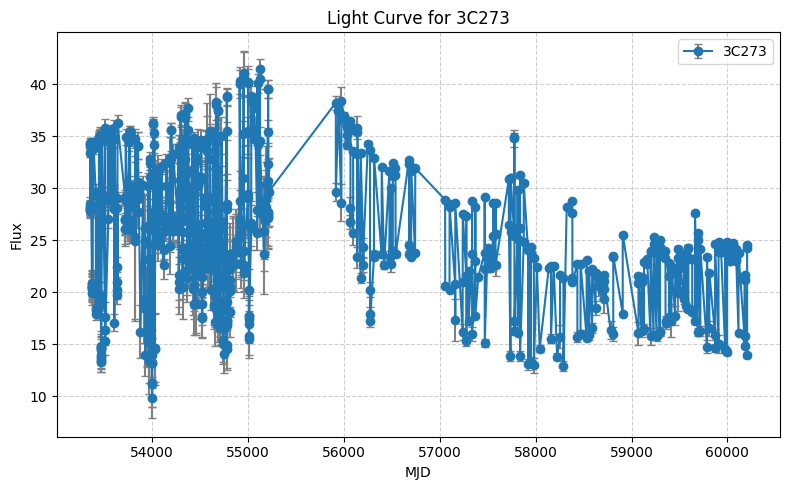

In [12]:



# Choose a source to plot, e.g. '3C273'
source_name = '3C273'

# Filter data for that source
src_data = combined[combined['Source'] == source_name]

# Sort by MJD to ensure chronological order
src_data = src_data.sort_values(by='MJD')

# --- Plot the light curve ---
plt.figure(figsize=(8,5))
plt.errorbar(src_data['MJD'], src_data['Flux'], yerr=src_data['Flux_err'],
             fmt='o-', ecolor='gray', capsize=3, label=source_name)

plt.title(f'Light Curve for {source_name}')
plt.xlabel('MJD')
plt.ylabel('Flux')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## filtering the frequencies

In [13]:
data_5 = data_lc[(data_lc['Freq'] >= 4000) & (data_lc['Freq'] <= 6000)]
data_8 = data_lc[(data_lc['Freq'] >= 7000) & (data_lc['Freq'] <= 10000)]
data_23 = data_lc[(data_lc['Freq'] >= 20000) & (data_lc['Freq'] <= 30000)]
data_43 = data_lc[(data_lc['Freq'] >= 40000) & (data_lc['Freq'] <= 60000)]

In [13]:
# --- Filter data for desired frequency range (4000–6000 MHz) ---
data_5 = data_lc[(data_lc['Freq'] >= 4000) & (data_lc['Freq'] <= 6000)]

# --- Group by Source only ---
for src, group in data_subset.groupby('Source'):
    group = group.sort_values(['MJD', 'Freq']).reset_index(drop=True)
    n = len(group)

    for i in range(n):
        mjd_i = group.loc[i, 'MJD']
        flux_i = group.loc[i, 'Flux']

        # Select later measurements 15–45 days apart
        mask = (group['MJD'] - mjd_i >= 15) & (group['MJD'] - mjd_i <= 45)
        valid_rows = group[mask]

        for j, row in valid_rows.iterrows():
            diff_results.append({
                'Source': src,
                'Freq_1': group.loc[i, 'Freq'],
                'Freq_2': row['Freq'],
                'MJD_1': mjd_i,
                'MJD_2': row['MJD'],
                'MJD_diff': row['MJD'] - mjd_i,
                'Flux_1': flux_i,
                'Flux_2': row['Flux'],
                'Flux_diff': row['Flux'] - flux_i
            })

# --- Filter data for desired frequency range (7000–9000 MHz) ---
data_8 = data_lc[(data_lc['Freq'] >= 7000) & (data_lc['Freq'] <= 9000)]

# --- Group by Source only ---
diff_results = []  # reset to store only this frequency range's results

for src, group in data_subset.groupby('Source'):
    group = group.sort_values(['MJD', 'Freq']).reset_index(drop=True)
    n = len(group)

    for i in range(n):
        mjd_i = group.loc[i, 'MJD']
        flux_i = group.loc[i, 'Flux']

        # Select later measurements 15–45 days apart
        mask = (group['MJD'] - mjd_i >= 15) & (group['MJD'] - mjd_i <= 45)
        valid_rows = group[mask]

        for j, row in valid_rows.iterrows():
            diff_results.append({
                'Source': src,
                'Freq_1': group.loc[i, 'Freq'],
                'Freq_2': row['Freq'],
                'MJD_1': mjd_i,
                'MJD_2': row['MJD'],
                'MJD_diff': row['MJD'] - mjd_i,
                'Flux_1': flux_i,
                'Flux_2': row['Flux'],
                'Flux_diff': row['Flux'] - flux_i
            })

# --- Filter data for desired frequency range (20 000–25 000 MHz) ---
data_23 = data_lc[(data_lc['Freq'] >= 20000) & (data_lc['Freq'] <= 25000)]

# --- Compute flux differences for 15–45 day intervals (grouped by Source) ---
diff_results = []

for src, group in data_subset.groupby('Source'):
    group = group.sort_values(['MJD', 'Freq']).reset_index(drop=True)
    n = len(group)

    for i in range(n):
        mjd_i = group.loc[i, 'MJD']
        flux_i = group.loc[i, 'Flux']

        # Select later measurements 15–45 days apart
        mask = (group['MJD'] - mjd_i >= 15) & (group['MJD'] - mjd_i <= 45)
        valid_rows = group[mask]

        for _, row in valid_rows.iterrows():
            diff_results.append({
                'Source': src,
                'Freq_1': group.loc[i, 'Freq'],
                'Freq_2': row['Freq'],
                'MJD_1': mjd_i,
                'MJD_2': row['MJD'],
                'MJD_diff': row['MJD'] - mjd_i,
                'Flux_1': flux_i,
                'Flux_2': row['Flux'],
                'Flux_diff': row['Flux'] - flux_i
            })


# --- Filter data for desired frequency range (40 000–45 000 MHz) ---
data_43 = data_lc[(data_lc['Freq'] >= 40000) & (data_lc['Freq'] <= 45000)]

# --- Compute flux differences for 15–45 day intervals (grouped by Source) ---
diff_results = []

for src, group in data_subset.groupby('Source'):
    group = group.sort_values(['MJD', 'Freq']).reset_index(drop=True)
    n = len(group)

    for i in range(n):
        mjd_i = group.loc[i, 'MJD']
        flux_i = group.loc[i, 'Flux']

        # Select later measurements 15–45 days apart
        mask = (group['MJD'] - mjd_i >= 15) & (group['MJD'] - mjd_i <= 45)
        valid_rows = group[mask]

        for _, row in valid_rows.iterrows():
            diff_results.append({
                'Source': src,
                'Freq_1': group.loc[i, 'Freq'],
                'Freq_2': row['Freq'],
                'MJD_1': mjd_i,
                'MJD_2': row['MJD'],
                'MJD_diff': row['MJD'] - mjd_i,
                'Flux_1': flux_i,
                'Flux_2': row['Flux'],
                'Flux_diff': row['Flux'] - flux_i
            })




NameError: name 'data_subset' is not defined

In [20]:
data_43

,Source,HHMMSS,MJD,Freq,elev,Flux,Flux_err
192,0235+164,75052.0,53854.327,43000.0,0.0,1.504,0.703
193,0235+164,45052.0,53879.202,43000.0,0.0,1.759,0.705
194,0235+164,65150.0,53879.286,43000.0,0.0,1.703,0.499
196,0235+164,25121.0,53911.119,43000.0,0.0,1.838,0.770
197,0235+164,45052.0,53913.202,43000.0,0.0,1.808,0.609
...,...,...,...,...,...,...,...
20251,OJ287,230643.0,55210.963,43000.0,0.0,10.546,1.253
20252,OJ287,193921.0,55213.819,43000.0,0.0,12.440,1.224
20253,OJ287,200643.0,55213.838,43000.0,0.0,13.430,1.407
20254,OJ287,200350.0,55214.836,43000.0,0.0,13.159,1.412


# PRELIMINARY

In [21]:
print("DataFrame Shape:", data_lc.shape, "\n\n"
      "Duplicated Rows:", data_lc.duplicated().sum(), "\n\n"
      "Missing Values:", data_lc.isnull().sum())

DataFrame Shape: (21094, 7) 

Duplicated Rows: 258 

Missing Values: Source      0
HHMMSS      8
MJD         8
Freq        8
elev        8
Flux        8
Flux_err    8
dtype: int64


In [22]:
data_lc

,Source,HHMMSS,MJD,Freq,elev,Flux,Flux_err
0,***,NaN,NaN,NaN,NaN,NaN,NaN
1,0235+164,185316.0,53349.78700,8000.0,0.0000,1.5050,0.0640
2,0235+164,212428.0,53349.89200,8000.0,0.0000,1.4770,0.0690
3,0235+164,232107.0,53349.97300,8000.0,0.0000,1.4920,0.0660
4,0235+164,12624.0,53350.06000,8000.0,0.0000,1.5360,0.0870
...,...,...,...,...,...,...,...
21089,TXS0536+145,173337.0,56272.74219,5125.0,13.4670,0.4973,0.0552
21090,TXS0536+145,203437.0,56272.86719,5125.0,44.8664,0.5468,0.0332
21091,TXS0536+145,224318.0,56272.95703,8305.0,59.3862,0.4248,0.0803
21092,TXS0536+145,21153.0,56273.10156,8305.0,41.8858,0.5773,0.0895


# EDA

In [23]:
fs = data_lc.groupby(['Source','Freq']).describe(include='number').T.loc['Flux']
fs.to_csv('lca_products/flux_statistics.csv')

In [24]:
data_5['Flux_diff'] = data_5.groupby(['Source', 'Freq'])['Flux'].diff()
data_8['Flux_diff'] = data_8.groupby(['Source', 'Freq'])['Flux'].diff()
data_23['Flux_diff'] = data_23.groupby(['Source', 'Freq'])['Flux'].diff()
data_43['Flux_diff'] = data_43.groupby(['Source', 'Freq'])['Flux'].diff()


C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_37880\3486725366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_5['Flux_diff'] = data_5.groupby(['Source', 'Freq'])['Flux'].diff()
C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_37880\3486725366.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_8['Flux_diff'] = data_8.groupby(['Source', 'Freq'])['Flux'].diff()
C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_37880\3486725366.py:3: SettingWithCopyWarning: 
A value is trying to be set on a co

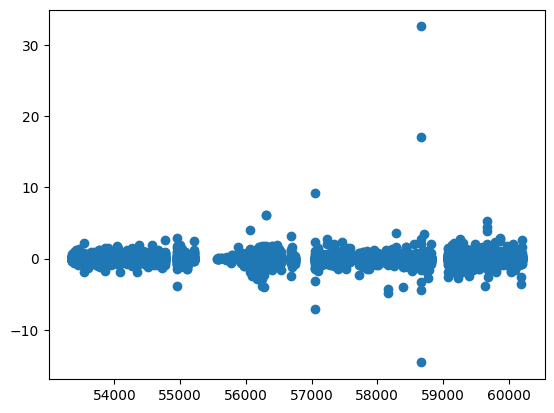

In [25]:
plt.figure()
plt.plot(data_8['MJD'], data_8['Flux_diff'], 'o')

In [26]:
import pandas as pd

def compute_flux_differences(data_subset, name=None):
    """
    Compute flux differences for points separated by 15–45 days within each Source.
    
    Parameters:
        data_subset (pd.DataFrame): Must contain ['Source', 'Freq', 'MJD', 'Flux']
        name (str, optional): Label for the frequency band (e.g., '5GHz')
    
    Returns:
        pd.DataFrame: Flux difference results
    """
    diff_results = []

    for src, group in data_subset.groupby('Source'):
        group = group.sort_values(['MJD', 'Freq']).reset_index(drop=True)
        n = len(group)

        for i in range(n):
            mjd_i = group.loc[i, 'MJD']
            flux_i = group.loc[i, 'Flux']

            # Select later measurements 15–45 days apart
            mask = (group['MJD'] - mjd_i >= 15) & (group['MJD'] - mjd_i <= 45)
            valid_rows = group[mask]

            for _, row in valid_rows.iterrows():
                diff_results.append({
                    'Source': src,
                    'Band': name,
                    'Freq_1': group.loc[i, 'Freq'],
                    'Freq_2': row['Freq'],
                    'MJD_1': mjd_i,
                    'MJD_2': row['MJD'],
                    'MJD_diff': row['MJD'] - mjd_i,
                    'Flux_1': flux_i,
                    'Flux_2': row['Flux'],
                    'Flux_diff': row['Flux'] - flux_i
                })

    return pd.DataFrame(diff_results)


In [27]:
flux_diff_5  = compute_flux_differences(data_5,  name='5GHz')
flux_diff_8  = compute_flux_differences(data_8,  name='8GHz')
flux_diff_23 = compute_flux_differences(data_23, name='23GHz')
flux_diff_43 = compute_flux_differences(data_43, name='43GHz')


flux_diff_5


,Source,Band,Freq_1,Freq_2,MJD_1,MJD_2,MJD_diff,Flux_1,Flux_2,Flux_diff
0,0235+164,5GHz,5000.0,5000.0,53354.71300,53381.71200,26.99900,1.3940,1.3210,-0.0730
1,0235+164,5GHz,5000.0,5000.0,53354.71300,53383.73800,29.02500,1.3940,1.2400,-0.1540
2,0235+164,5GHz,5000.0,5000.0,53354.71300,53384.76100,30.04800,1.3940,1.2530,-0.1410
3,0235+164,5GHz,5000.0,5000.0,53354.71300,53385.73800,31.02500,1.3940,1.2550,-0.1390
4,0235+164,5GHz,5000.0,5000.0,53354.71300,53386.73800,32.02500,1.3940,1.2630,-0.1310
...,...,...,...,...,...,...,...,...,...,...
4350,SgrA,5GHz,5125.0,5125.0,56511.79688,56538.71875,26.92187,182.9798,171.1124,-11.8674
4351,SgrA,5GHz,5075.0,5075.0,56702.31254,56745.20172,42.88918,181.9101,177.5933,-4.3168
4352,TXS0536+145,5GHz,5125.0,5125.0,56037.44141,56068.45312,31.01171,0.2482,0.2980,0.0498
4353,TXS0536+145,5GHz,5125.0,5125.0,56037.46094,56068.45312,30.99218,0.2728,0.2980,0.0252


In [ ]:



df = flux_diff_43        
band_name = "43GHz"
output_dir = f"lca_products/images/returns/{band_name}"
os.makedirs(output_dir, exist_ok=True)

saved_count = 0

for src, group in df.groupby('Source'):
    if group.empty:
        continue

    flux_diff = group['Flux_diff']

    median = np.median(flux_diff)
    p16 = np.percentile(flux_diff, 16)
    p84 = np.percentile(flux_diff, 84)


    plt.figure(figsize=(7,5))
    counts, bins, _ = plt.hist(flux_diff, bins=30, alpha=0.5, edgecolor='black', color='navy')

    plt.axvspan(p16, p84, color='navy', alpha=0.3, label='16–84 percentile')

    plt.axvline(median, color='k', linestyle='--', linewidth=2, label='Median',alpha=0.5)

    plt.title(f"Flux Differences (15–45 days)\nSource: {src} ({band_name})")
    plt.xlabel("Δ Flux")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

 
    safe_src = str(src).replace(' ', '_').replace('/', '_')
    file_path = os.path.join(output_dir, f"flux_diff_hist_{safe_src}_{band_name}.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.close()
    saved_count += 1

print(f"✅ Saved {saved_count} histograms with median and shaded 16–84 percentile in {output_dir}")






✅ Saved 34 histograms with median and shaded 16–84 percentile in lca_products/images/returns/43GHz


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


output_dir = "lca_products/images/returns/fluxcorr_43_vs_23"
os.makedirs(output_dir, exist_ok=True)


data_43 = data_43.sort_values(['Source', 'MJD']).reset_index(drop=True)
data_23 = data_23.sort_values(['Source', 'MJD']).reset_index(drop=True)

common_sources = sorted(set(data_43['Source']) & set(data_23['Source']))
saved_count = 0

for src in common_sources:
    d43 = data_43[data_43['Source'] == src].copy()
    d23 = data_23[data_23['Source'] == src].copy()


    merged = pd.merge_asof(
        d43, d23,
        on='MJD', by='Source',
        suffixes=('_43', '_23'),
        tolerance=1,        # days
        direction='nearest'
    )

    merged = merged.dropna(subset=['Flux_43', 'Flux_23'])
    if merged.empty:
        print(f"⚠️ No matching MJDs found for {src}")
        continue

    corr = np.corrcoef(merged['Flux_43'], merged['Flux_23'])[0, 1]

    plt.figure(figsize=(7,6))
    sns.scatterplot(
        x='Flux_43', y='Flux_23', data=merged,
        color='dodgerblue', s=60, alpha=0.7, edgecolor='black',
        label=f'r = {corr:.2f}'
    )
    sns.regplot(
        x='Flux_43', y='Flux_23', data=merged,
        scatter=False, color='red', line_kws={'linewidth': 1.5, 'alpha': 0.8}
    )

 
    min_flux = min(merged['Flux_43'].min(), merged['Flux_23'].min())
    max_flux = max(merged['Flux_43'].max(), merged['Flux_23'].max())
    plt.plot([min_flux, max_flux], [min_flux, max_flux],
             color='gray', linestyle='--', label='1:1 line')

    plt.title(f"{src}: Flux Correlation (43 GHz vs 23 GHz)")
    plt.xlabel("Flux (43 GHz)")
    plt.ylabel("Flux (23 GHz)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

 
    safe_src = str(src).replace(' ', '_').replace('/', '_')
    file_path = os.path.join(output_dir, f"flux_corr_43_vs_23_{safe_src}.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.close()
    saved_count += 1

print(f"✅ Saved {saved_count} flux correlation plots (43 GHz vs 23 GHz) in {output_dir}")




c:\Users\Rupal Giri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Rupal Giri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Rupal Giri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


⚠️ No matching MJDs found for 1219+285
✅ Saved 33 flux correlation plots (43 GHz vs 23 GHz) in lca_products/images/returns/fluxcorr_43_vs_23


### Corr matrix

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


output_dir = "lca_products/images/returns/corr_matrices"
os.makedirs(output_dir, exist_ok=True)

for df in [data_5, data_8, data_23, data_43]:
    df.sort_values(['Source', 'MJD'], inplace=True)

common_sources = sorted(
    set(data_5['Source']) &
    set(data_8['Source']) &
    set(data_23['Source']) &
    set(data_43['Source'])
)

saved_count = 0

for src in common_sources:
    d5 = data_5[data_5['Source'] == src].copy()
    d8 = data_8[data_8['Source'] == src].copy()
    d23 = data_23[data_23['Source'] == src].copy()
    d43 = data_43[data_43['Source'] == src].copy()

    
    merged = pd.merge_asof(d5, d8, on='MJD', by='Source',
                           suffixes=('_5', '_8'),
                           tolerance=15, direction='nearest')
    merged = pd.merge_asof(merged, d23, on='MJD', by='Source',
                           suffixes=('', '_23'),
                           tolerance=15, direction='nearest')
    merged = pd.merge_asof(merged, d43, on='MJD', by='Source',
                           suffixes=('', '_43'),
                           tolerance=15, direction='nearest')


    flux_cols = {
        'Flux_5': 'Flux_5GHz',
        'Flux_8': 'Flux_8GHz',
        'Flux': 'Flux_23GHz',
        'Flux_43': 'Flux_43GHz'
    }
    merged = merged.rename(columns=flux_cols)

   
    flux_df = merged[['Flux_5GHz', 'Flux_8GHz', 'Flux_23GHz', 'Flux_43GHz']].dropna()

    if flux_df.empty:
        print(f"⚠️ No close MJD matches found for {src}")
        continue

  
    corr_matrix = flux_df.corr()

   
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
                square=True, cbar_kws={'label': 'Correlation Coefficient (r)'})
    plt.title(f"{src} — Flux Correlation Matrix (same MJD)")
    plt.tight_layout()

   
    safe_src = str(src).replace(' ', '_').replace('/', '_')
    file_path = os.path.join(output_dir, f"corr_matrix_{safe_src}.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.close()
    saved_count += 1

print(f"✅ Saved {saved_count} correlation matrices in {output_dir}")


✅ Saved 34 correlation matrices in lca_products/images/returns/corr_matrices


## MA

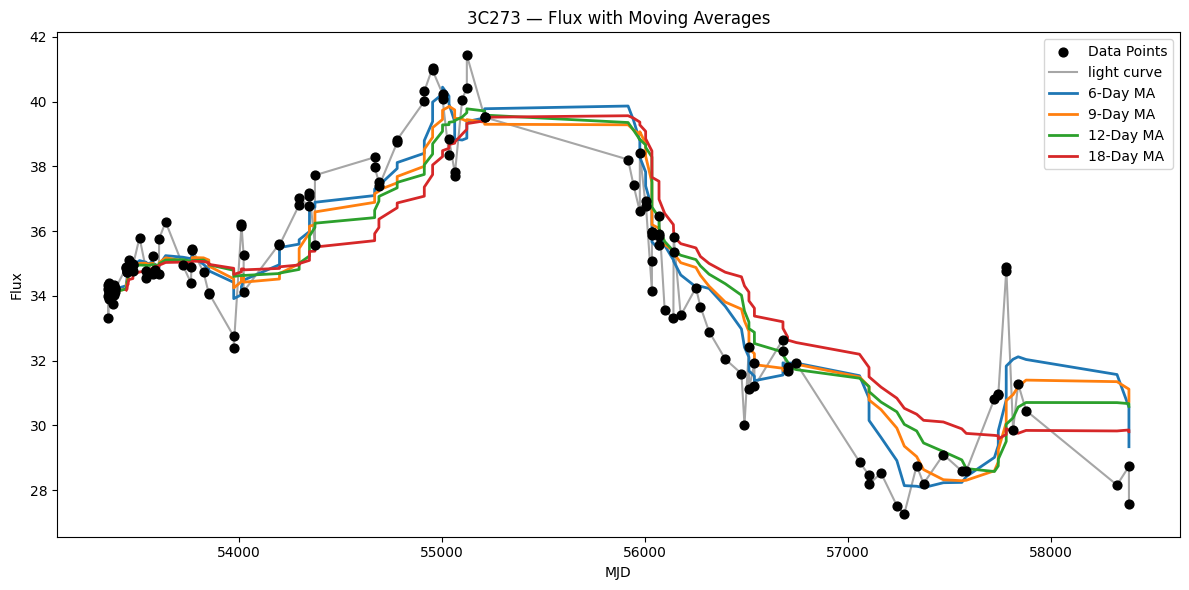

In [32]:


# Moving average windows
ma_windows = [6, 9, 12, 18]

# Select data for one source
data_test = data_5[data_5['Source'] == '3C273'].copy()

plt.figure(figsize=(12,6))

# Plot raw data points
plt.scatter(
    data_test['MJD'],
    data_test['Flux'],
    label="Data Points",
    color="black",
    s=40,  # marker size
    zorder=5
)

# Plot the flux line (optional, for visual continuity)
plt.plot(
    data_test['MJD'],
    data_test['Flux'],
    label="light curve",
    color="gray",
    linewidth=1.5,
    alpha=0.7
)

# Plot moving averages
for w in ma_windows:
    plt.plot(
        data_test['MJD'],
        data_test['Flux'].rolling(window=w).mean(),
        label=f"{w}-Day MA",
        linewidth=2
    )

plt.xlabel("MJD")
plt.ylabel("Flux")
plt.title("3C273 — Flux with Moving Averages")
plt.legend()
plt.tight_layout()
plt.show()



# Source analysis

In [45]:
f_data = pd.read_csv('Impfiles/Sources/filtered_data_3C454.3.csv')
f_data
source = 'MRK421'
source_data_bach = get_source_data(bach_data, source)
print(source_data_bach)

Empty DataFrame
Columns: [Source, HHMMSS, MJD, Freq, elev, Flux, Flux err]
Index: []


In [23]:
source= '3C84'
source_data_m = get_source_data(data2, source)
print(source_data_m)

     Source  HHMMSS          MJD     Freq     elev     Flux Flux_err e_Flux
20     3C84  155457  55220.66406  20000.0  63.9903  19.7712   0.4119    NaN
1272   3C84  153941  56288.65625   8305.0  56.5442   3.1449   0.1729    NaN
3822   3C84  080914  57947.34235  24100.0  78.0272  29.3930   0.8540    NaN
3833   3C84  123130  57947.52447  24100.0  32.8659  23.1330   1.2304    NaN
3843   3C84  070654  57981.29905  24100.0  65.3221  29.8255   0.8473    NaN
...     ...     ...          ...      ...      ...      ...      ...    ...
9522   3C84  024917  60116.11921  24100.0  29.6518  32.4271   0.4143    NaN
9529   3C84  045028  60116.20336  24100.0  49.4637  36.6486   0.3441    NaN
9530   3C84  070225  60116.29500  24100.0  72.7205  38.4841   0.3261    NaN
9605   3C84  102652  60179.43697  24100.0  27.7818  32.7692   0.3705    NaN
9616   3C84  074312  60205.32332  24100.0  37.4223  35.5793   0.5729    NaN

[130 rows x 8 columns]


Unique values in 'Freq' after conversion: [20000.  8305. 24100.  8520.  4835.  6075. 23840.]
Number of NaN values in 'Freq': 0


C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_21892\2789969110.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_data_m['Freq'] = pd.to_numeric(source_data_m['Freq'], errors='coerce')


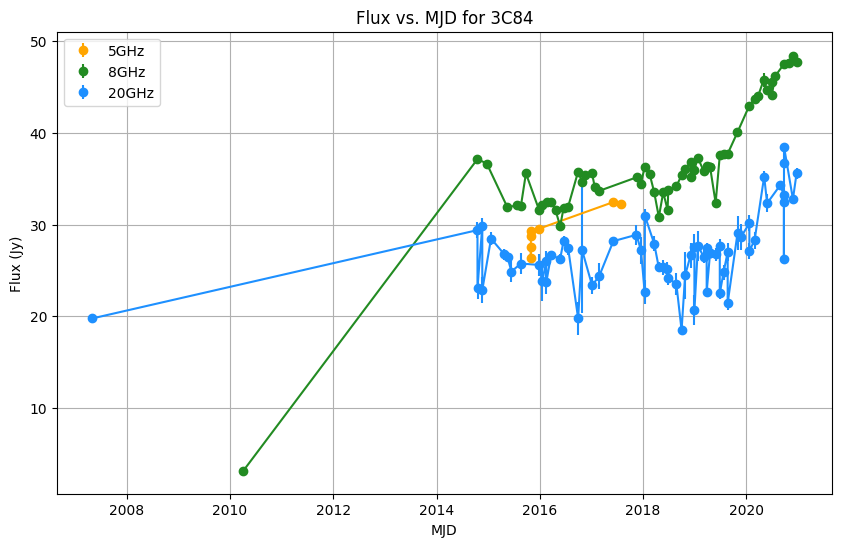

In [24]:
# Convert 'Freq' column to numeric, coercing errors to NaN
source_data_m['Freq'] = pd.to_numeric(source_data_m['Freq'], errors='coerce')

# Drop rows with NaN in 'Freq'
source_data_m = source_data_m.dropna(subset=['Freq'])

# Debugging: Check the 'Freq' column after conversion
print("Unique values in 'Freq' after conversion:", source_data_m['Freq'].unique())
print("Number of NaN values in 'Freq':", source_data_m['Freq'].isna().sum())

# Convert 'MJD' column to numeric, coercing errors to NaN
source_data_m['MJD'] = pd.to_numeric(source_data_m['MJD'], errors='coerce')

# Drop rows with NaN in 'MJD'
source_data_m = source_data_m.dropna(subset=['MJD'])

# Debugging: Check the 'MJD' column after conversion
#print("Unique values in 'MJD' after conversion:", source_data_m['MJD'].unique())
#print("Number of NaN values in 'MJD':", source_data_m['MJD'].isna().sum())

# Ensure 'Flux' and 'Flux_err' columns are numeric
source_data_m['Flux'] = pd.to_numeric(source_data_m['Flux'], errors='coerce')
source_data_m['Flux_err'] = pd.to_numeric(source_data_m['Flux_err'], errors='coerce')

# Drop rows with NaN in 'Flux' or 'Flux_err'
source_data_m = source_data_m.dropna(subset=['Flux', 'Flux_err'])

# Filter data based on frequency ranges
f_data_5 = source_data_m[(source_data_m['Freq'] >= 4000) & (source_data_m['Freq'] <= 7000)]
f_data_8 = source_data_m[(source_data_m['Freq'] >= 7000) & (source_data_m['Freq'] <= 9000)]
f_data_20 = source_data_m[(source_data_m['Freq'] >= 15000) & (source_data_m['Freq'] <= 30000)]

# Debugging: Check if filtered DataFrames are empty
#print("f_data_5 is empty:", f_data_5.empty)
#print("f_data_8 is empty:", f_data_8.empty)
#print("f_data_20 is empty:", f_data_20.empty)

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(1858 + ((f_data_5['MJD'] - 678.5) / 365.25), f_data_5['Flux'], yerr=f_data_5['Flux_err'], fmt='o', label='5GHz', color='orange')
plt.errorbar(1858 + ((f_data_8['MJD'] - 678.5) / 365.25), f_data_8['Flux'], yerr=f_data_8['Flux_err'], fmt='o', label='8GHz', color='forestgreen')
plt.errorbar(1858 + ((f_data_20['MJD'] - 678.5) / 365.25), f_data_20['Flux'], yerr=f_data_20['Flux_err'], fmt='o', label='20GHz', color='dodgerblue')
plt.plot(1858 + ((f_data_5['MJD'] - 678.5) / 365.25), f_data_5['Flux'], color='orange')
plt.plot(1858 + ((f_data_8['MJD'] - 678.5) / 365.25), f_data_8['Flux'], color='forestgreen')
plt.plot(1858 + ((f_data_20['MJD'] - 678.5) / 365.25), f_data_20['Flux'], color='dodgerblue')
plt.grid(True)
plt.xlabel('MJD')
plt.ylabel('Flux (Jy)')
plt.title('Flux vs. MJD for 3C84')
plt.legend()